In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [16]:
df = pd.read_csv('buyrentkenya_clean.csv')
df.shape
df.head()


,listing_id,title,price_kes,bedrooms,bathrooms,size_sqm,property_type,neighbourhood,county,listing_type,...,total_rooms,price_per_sqm,bedroom_category,url,scraped_at,price_raw,bedrooms_raw,bathrooms_raw,size_raw,location
0,3929132,5 Bed Townhouse with En Suite in Lavington,95000000.0,5.0,6.0,NaN,Townhouse,Lavington,NaN,sale,...,11.0,NaN,4-5 Bed,https://www.buyrentkenya.com/listings/5-bedroo...,2026-03-05 16:58,"KSh 95,000,000",5 Bedrooms,6 Bathrooms,NaN,NaN
1,3899840,3 Bed Townhouse with En Suite at Dagoretti Road,22500000.0,3.0,3.0,223.0,Townhouse,Gikambura,Kikuyu,sale,...,6.0,100897.0,3 Bed,https://www.buyrentkenya.com/listings/3-bedroo...,2026-03-05 16:58,"KSh 22,500,000",3 Bedrooms,3 Bathrooms,223 m²,"Gikambura, Kikuyu"
2,3923500,6 Bed House with En Suite in Thigiri,260000000.0,6.0,6.0,NaN,House,Thigiri,Westlands,sale,...,12.0,NaN,6+ Bed,https://www.buyrentkenya.com/listings/6-bedroo...,2026-03-05 16:58,"KSh 260,000,000",6 Bedrooms,6 Bathrooms,NaN,"Thigiri, Westlands"
3,3936874,4 Bed Townhouse with En Suite at Muhuri Road,25000000.0,4.0,5.0,240.0,Townhouse,Cascading Ridge Views Estate,New,sale,...,9.0,104167.0,4-5 Bed,https://www.buyrentkenya.com/listings/4-bedroo...,2026-03-05 16:58,"KSh 25,000,000",4 Bedrooms,5 Bathrooms,240 m²,"Cascading Ridge Views Estate, New"
4,3934405,5 Bed House with En Suite at Riverside,7800000.0,5.0,4.0,200.0,House,Riverside,NaN,sale,...,9.0,39000.0,4-5 Bed,https://www.buyrentkenya.com/listings/5-bedroo...,2026-03-05 16:58,"KSh 7,800,000",5 Bedrooms,4 Bathrooms,200 m²,NaN


In [17]:
df.describe().round(2)

,listing_id,price_kes,bedrooms,bathrooms,size_sqm,is_sale,is_nairobi,total_rooms,price_per_sqm
count,1733.00,1.733000e+03,1733.00,1658.00,391.00,1733.0,1733.00,1733.00,3.910000e+02
mean,3917386.03,4.243202e+07,4.35,4.63,263.75,0.5,0.60,8.78,2.421309e+07
std,103510.11,6.589515e+07,1.02,1.26,2354.31,0.5,0.49,2.35,5.750164e+07
min,27939.00,4.000000e+04,1.00,1.00,0.20,0.0,0.00,1.00,3.340000e+02
25%,3921521.00,3.870000e+05,4.00,4.00,5.00,0.0,0.00,8.00,6.552350e+04
50%,3928708.00,5.000000e+06,4.00,5.00,13.00,1.0,1.00,9.00,1.406250e+05
75%,3933980.00,7.500000e+07,5.00,5.00,257.00,1.0,1.00,10.00,1.800000e+07
max,3939579.00,4.500000e+08,10.00,10.00,46452.00,1.0,1.00,20.00,4.000000e+08


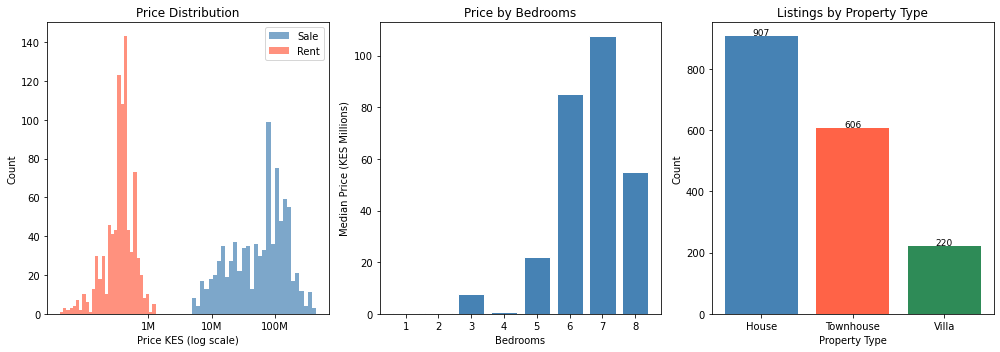

Saved: eda_01_overview.png


In [18]:
#EDA
plt.figure(figsize=(14, 5))

# Chart 1: Price histogram by listing type
plt.subplot(1, 3, 1)
sale_prices = df[df['listing_type'] == 'sale']['price_kes']
rent_prices = df[df['listing_type'] == 'rent']['price_kes']
plt.hist(np.log10(sale_prices), bins=30, alpha=0.7, color='steelblue', label='Sale')
plt.hist(np.log10(rent_prices), bins=30, alpha=0.7, color='tomato',    label='Rent')
plt.xlabel('Price KES (log scale)')
plt.ylabel('Count')
plt.title('Price Distribution')
plt.xticks([6, 7, 8], ['1M', '10M', '100M'])
plt.legend()

# Chart 2: Median price by bedrooms
plt.subplot(1, 3, 2)
bed_price = df.groupby('bedrooms')['price_kes'].median().reset_index()
bed_price  = bed_price[bed_price['bedrooms'] <= 8]
plt.bar(bed_price['bedrooms'].astype(int), bed_price['price_kes'] / 1e6,
        color='steelblue', edgecolor='white')
plt.xlabel('Bedrooms')
plt.ylabel('Median Price (KES Millions)')
plt.title('Price by Bedrooms')

# Chart 3: Count by property type
plt.subplot(1, 3, 3)
prop_counts = df['property_type'].value_counts()
plt.bar(prop_counts.index, prop_counts.values, color=['steelblue','tomato','seagreen'])
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.title('Listings by Property Type')
for i, v in enumerate(prop_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_01_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_01_overview.png")


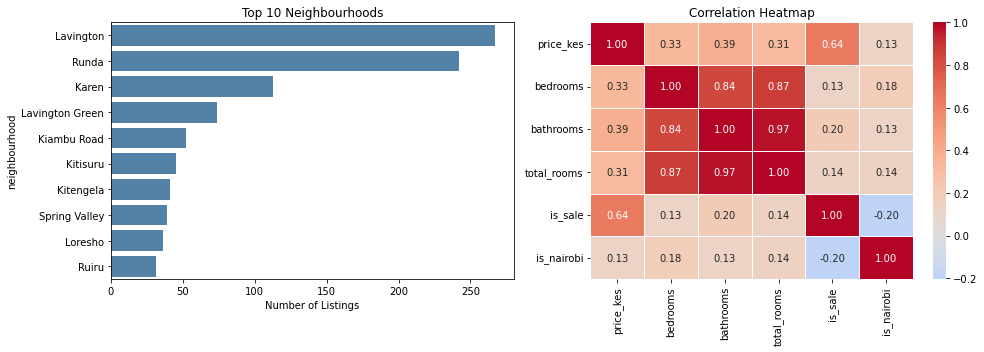

Saved: eda_02_correlation.png

Correlation with price_kes:
is_sale        0.636935
bathrooms      0.387235
bedrooms       0.334903
total_rooms    0.313197
is_nairobi     0.133588
Name: price_kes, dtype: float64


In [19]:
#Neighbourhood & Correlations
plt.figure(figsize=(14, 5))

# Chart 4: Top 10 neighbourhoods
plt.subplot(1, 2, 1)
top10 = df['neighbourhood'].value_counts().head(10)
sns.barplot(x=top10.values, y=top10.index, color='steelblue')
plt.xlabel('Number of Listings')
plt.title('Top 10 Neighbourhoods')

# Chart 5: Correlation heatmap
plt.subplot(1, 2, 2)
num_cols = ['price_kes', 'bedrooms', 'bathrooms', 'total_rooms', 'is_sale', 'is_nairobi']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_02_correlation.png")

# Print correlation with price
print("\nCorrelation with price_kes:")
print(corr['price_kes'].drop('price_kes').sort_values(ascending=False))



In [20]:
#prepare Features for Model
features = ['bedrooms', 'bathrooms', 'is_sale', 'is_nairobi', 'total_rooms', 'property_type_encoded']
target   = 'price_kes'

# Encode property_type as a number
le = LabelEncoder()
df['property_type_encoded'] = le.fit_transform(df['property_type'])
print(f"\nProperty type encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Drop rows with any missing values in our feature columns
data = df[features + [target]].dropna()
print(f"\nRows available for modelling: {len(data):,}")
print(f"Features used: {features}")

X = data[features]
y = data[target]



Property type encoding: {'House': np.int64(0), 'Townhouse': np.int64(1), 'Villa': np.int64(2)}

Rows available for modelling: 1,658
Features used: ['bedrooms', 'bathrooms', 'is_sale', 'is_nairobi', 'total_rooms', 'property_type_encoded']


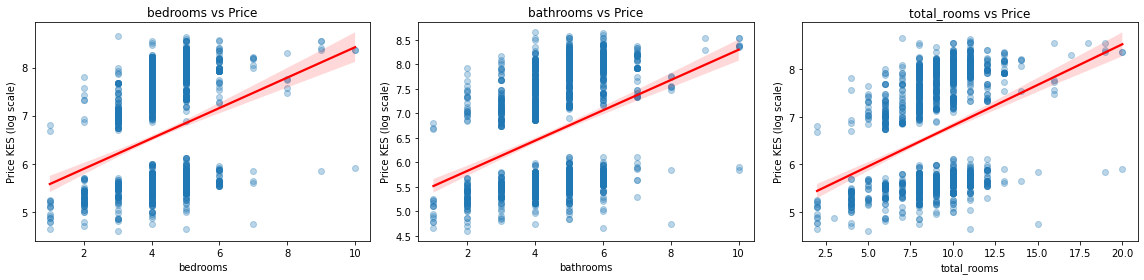

Saved: eda_04_feature_vs_price.png


In [21]:
 #Data Visualization Features vs Price
plt.figure(figsize=(16, 4))

for i, col in enumerate(['bedrooms', 'bathrooms', 'total_rooms']):
    plt.subplot(1, 3, i + 1)
    sns.regplot(x=data[col], y=np.log10(y), line_kws={'color': 'red'}, scatter_kws={'alpha': 0.3})
    plt.xlabel(col)
    plt.ylabel('Price KES (log scale)')
    plt.title(f'{col} vs Price')

plt.tight_layout()
plt.savefig('eda_04_feature_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_04_feature_vs_price.png")

In [22]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)

In [23]:
# Evaluate the Model

r2   = r2_score(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Model Performance — Random Forest")
print(f"R² Score : {r2:.4f}  ({r2*100:.1f}% of price variance explained)")
print(f"RMSE     : KES {rmse:,.0f}")


Model Performance — Random Forest
R² Score : 0.6827  (68.3% of price variance explained)
RMSE     : KES 35,642,859


In [24]:
#Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

print(f"\nFeature Importances:")
for feat, score in importances.items():
    print(f"  {feat:<25} {score:.4f}")


Feature Importances:
  is_sale                   0.5419
  bedrooms                  0.1350
  is_nairobi                0.1187
  total_rooms               0.0898
  bathrooms                 0.0650
  property_type_encoded     0.0496


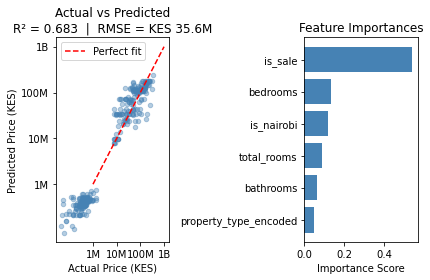

Saved: model_results.png


In [25]:
# Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(np.log10(y_test), np.log10(predictions), alpha=0.4, color='steelblue', s=20)
plt.plot([6, 9], [6, 9], 'r--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual Price (KES)')
plt.ylabel('Predicted Price (KES)')
plt.title(f'Actual vs Predicted\nR² = {r2:.3f}  |  RMSE = KES {rmse/1e6:.1f}M')
plt.xticks([6, 7, 8, 9], ['1M', '10M', '100M', '1B'])
plt.yticks([6, 7, 8, 9], ['1M', '10M', '100M', '1B'])
plt.legend()

# Feature Importances
plt.subplot(1, 2, 2)
importances_sorted = importances.sort_values(ascending=True)
plt.barh(importances_sorted.index, importances_sorted.values, color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importances')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_results.png")

In [34]:
# Predict on Sample Properties
# Encoding used: House=0, Townhouse=1, Villa=2
sample = pd.DataFrame([
    [3, 3, 1, 1, 6,  1],
    [4, 4, 1, 0, 8,  0],
    [5, 5, 1, 1, 10, 2],  
    [2, 2, 0, 1, 4,  0],  
    [4, 3, 0, 0, 7,  1],   
], columns=features)

descriptions = [
    '3-bed Townhouse | For Sale | Nairobi',
    '4-bed House     | For Sale | Outside Nairobi',
    '5-bed Villa     | For Sale | Nairobi',
    '2-bed House     | For Rent | Nairobi',
    '4-bed Townhouse | For Rent | Outside Nairobi',
]


sample_predictions = rf_model.predict(sample)
print(sample_predictions)
print(f"{'Property':<45} {'Predicted Price':>15}")
print("-" * 62)
for desc, pred in zip(descriptions, sample_predictions):
    print(f"{desc:<45} KES {pred:>12,.0f}")

[4.17848841e+07 3.32888883e+07 1.46218333e+08 2.15506318e+05
 2.55467902e+05]
Property                                      Predicted Price
--------------------------------------------------------------
3-bed Townhouse | For Sale | Nairobi          KES   41,784,884
4-bed House     | For Sale | Outside Nairobi  KES   33,288,888
5-bed Villa     | For Sale | Nairobi          KES  146,218,333
2-bed House     | For Rent | Nairobi          KES      215,506
4-bed Townhouse | For Rent | Outside Nairobi  KES      255,468
